In [ ]:
# This notebook is used as playground to practice basic pytorch workflow
# From working with dataset, initializing model to its training and eval, making predictions, loading and saving of model
# In this notebook we will experiment with multiple linear regresssion

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [3]:
weight_1 = 0.56
weight_2 = 0.32
bias = 0.9

start = 0
end = 1
step = 0.01

x1 = torch.arange(start, end, step).unsqueeze(dim=1)
x2 = torch.arange(start, end, step).unsqueeze(dim=1)

X = torch.stack((x1, x2), dim=1).squeeze(-1)
y = weight_1 * x1 + weight_2 * x2 + bias

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: torch.Size([100, 2])
y shape: torch.Size([100, 1])


In [4]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: torch.Size([80, 2])
y_train shape: torch.Size([80, 1])
X_test shape: torch.Size([20, 2])
y_test shape: torch.Size([20, 1])


In [5]:
# plotting is harder since we are in 3D now

In [6]:
class MultipleLinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=2, out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

In [7]:
model = MultipleLinearRegression()
model.state_dict()

model.to(device)

MultipleLinearRegression(
  (linear_layer): Linear(in_features=2, out_features=1, bias=True)
)

In [8]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [9]:
### Training
torch.manual_seed(42)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

train_loss_values = []
test_loss_values = []
epoch_values = []

EPOCHS = 300

for epoch in range(EPOCHS):
  model.train()

  y_pred = model(X_train)
  loss = loss_fn(y_pred, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 20 == 0:
    model.eval()
    with torch.no_grad():
      y_test_pred = model(X_test)
      test_loss = loss_fn(y_test_pred, y_test)
      print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")
      train_loss_values.append(loss.cpu())
      test_loss_values.append(test_loss.cpu())
      epoch_values.append(epoch)

Epoch: 0 | Train loss: 1.64704167842865 | Test loss: 2.155987024307251
Epoch: 20 | Train loss: 1.3846317529678345 | Test loss: 1.8145771026611328
Epoch: 40 | Train loss: 1.122221827507019 | Test loss: 1.4731669425964355
Epoch: 60 | Train loss: 0.8598117828369141 | Test loss: 1.1317570209503174
Epoch: 80 | Train loss: 0.5974019765853882 | Test loss: 0.790347158908844
Epoch: 100 | Train loss: 0.3349921405315399 | Test loss: 0.44893738627433777
Epoch: 120 | Train loss: 0.07258232682943344 | Test loss: 0.10752756893634796
Epoch: 140 | Train loss: 0.0027980543673038483 | Test loss: 0.004559201188385487
Epoch: 160 | Train loss: 0.010708297602832317 | Test loss: 0.0007063746452331543
Epoch: 180 | Train loss: 0.010708297602832317 | Test loss: 0.0007063746452331543
Epoch: 200 | Train loss: 0.010708297602832317 | Test loss: 0.0007063746452331543
Epoch: 220 | Train loss: 0.010708297602832317 | Test loss: 0.0007063746452331543
Epoch: 240 | Train loss: 0.010708297602832317 | Test loss: 0.0007063746

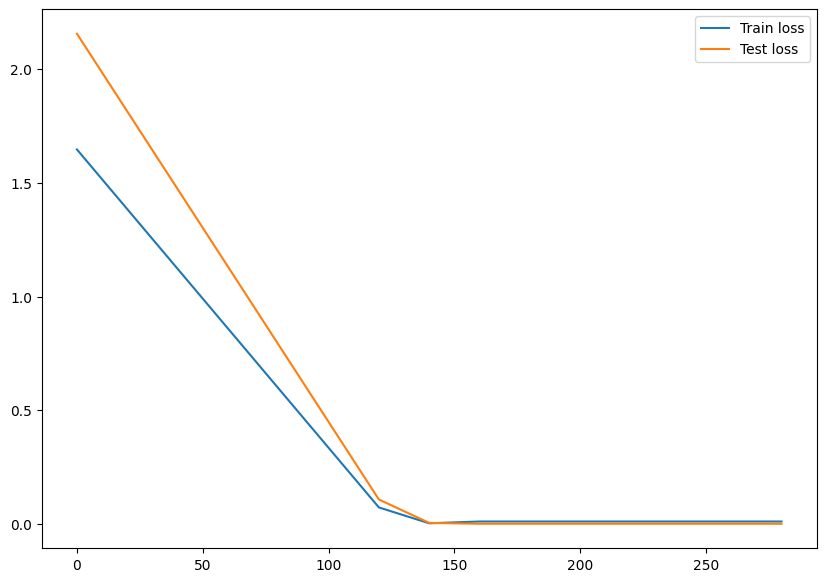

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(epoch_values, train_loss_values, label="Train loss")
ax.plot(epoch_values, test_loss_values, label="Test loss")
ax.legend()

In [11]:
model.eval()

with torch.inference_mode():
  y_preds = model(X_test)

y_preds

tensor([[1.5887],
        [1.5974],
        [1.6061],
        [1.6148],
        [1.6235],
        [1.6321],
        [1.6408],
        [1.6495],
        [1.6582],
        [1.6669],
        [1.6756],
        [1.6843],
        [1.6930],
        [1.7016],
        [1.7103],
        [1.7190],
        [1.7277],
        [1.7364],
        [1.7451],
        [1.7538]], device='cuda:0')

In [12]:
torch.save(obj=model.state_dict(), f="model.pth")

In [13]:
loaded_model = MultipleLinearRegression()
loaded_model.load_state_dict(torch.load("model.pth"))
loaded_model.to(device)

MultipleLinearRegression(
  (linear_layer): Linear(in_features=2, out_features=1, bias=True)
)

In [14]:
model.eval()

with torch.inference_mode():
  loaded_preds = loaded_model(X_test)

loaded_preds == y_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')